# Figure A3: Optimality of Simple Imputation (Supplementary)

This notebook investigates whether sophisticated imputation methods can improve upon the simple missing-as-zero approach for PLS-SVD under MCAR missingness. The theoretical analysis predicts that PLS-SVD with proper normalization achieves optimal recovery—we test whether more complex methods can exceed this limit.

**Key question:** Does sophisticated imputation help, or is simple optimal?

**Methods compared:**
- PLS-SVD: Missing-as-zero with prewhitening (the method analyzed theoretically)
- Mean Imputation: Replace missing with column means
- EM-PLS: Probabilistic PLS via EM algorithm
- Iterative SVD: Low-rank SVD imputation + PLS
- Oracle: Upper bound with no missing data (complete data)

**Figure layout (3 panels):**
- (a) Phase transition curves: all methods vs theory (θ sweep)
- (b) Method comparison across missingness rates (m sweep at fixed supercritical θ)
- (c) Computational cost vs accuracy trade-off

In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from multiprocessing import Pool
from tqdm.notebook import tqdm

from src import (
    ModelParams, theoretical_overlaps,
    run_multiple_trials_all_methods, _run_all_methods_worker, _run_all_methods_missingness_worker
)

# ICML-compatible styling
plt.rcParams.update({
    'font.size': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7,
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

np.random.seed(42)

## 1. Define Methods

| Method | Description | Expected Performance |
|--------|-------------|---------------------|
| PLS-SVD | Missing-as-zero + prewhitening | Matches theory (optimal for MCAR) |
| Mean Imputation | Column mean substitution | Possibly biased at high missingness |
| EM-PLS | Iterative imputation | May help near threshold? |
| Iterative SVD | Low-rank completion | Good for structured missing? |
| Oracle | No missing data | Upper bound (complete data) |

In [2]:
# Method metadata
METHODS = {
    'pls': {
        'label': 'PLS-SVD',
        'key': 'Rx2_pls',
        'time_key': 'time_pls',
        'color': 'C0',
        'marker': 'o',
        'linestyle': '-',
    },
    'mean_imp': {
        'label': 'Mean Imputation',
        'key': 'Rx2_mean_imp',
        'time_key': 'time_mean_imp',
        'color': 'C1',
        'marker': 's',
        'linestyle': '-',
    },
    'em_pls': {
        'label': 'EM-PLS',
        'key': 'Rx2_em_pls',
        'time_key': 'time_em_pls',
        'color': 'C2',
        'marker': 'v',
        'linestyle': '-',
    },
    'iter_svd': {
        'label': 'Iterative SVD',
        'key': 'Rx2_iter_svd',
        'time_key': 'time_iter_svd',
        'color': 'C3',
        'marker': 'd',
        'linestyle': '-',
    },
    'oracle': {
        'label': 'Oracle (complete data)',
        'key': 'Rx2_oracle',
        'time_key': 'time_oracle',
        'color': 'C4',
        'marker': '*',
        'linestyle': '--',
    },
}

print("Methods to compare:")
for name, info in METHODS.items():
    print(f"  {info['label']}")

Methods to compare:
  PLS-SVD
  Mean Imputation
  EM-PLS
  Iterative SVD
  Oracle (complete data)


## 2. Experiment Setup

In [3]:
# Fixed parameters
N = 1000
Dx = 200
Dy = 150
n_trials = 50

# For theta sweep (Experiment A)
m_fixed = 0.3
alpha_x = N / Dx
alpha_y = N / Dy
rho_fixed = (1 - m_fixed) ** 2
theta_crit_fixed = 1 / ((alpha_x * alpha_y) ** 0.25 * np.sqrt(rho_fixed))
theta_values = np.linspace(0.5 * theta_crit_fixed, 2.0 * theta_crit_fixed, 20)

# For missingness sweep (Experiment B)
m_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
theta_supercrit_factor = 1.5  # theta = 1.5 * theta_crit for each m

print(f"Parameters:")
print(f"  N={N}, Dx={Dx}, Dy={Dy}")
print(f"  For θ sweep: m={m_fixed}, ρ={rho_fixed:.2f}, θ_crit={theta_crit_fixed:.4f}")
print(f"  For m sweep: θ = 1.5 × θ_crit(m)")
print(f"  n_trials = {n_trials}")

Parameters:
  N=1000, Dx=200, Dy=150
  For θ sweep: m=0.3, ρ=0.49, θ_crit=0.5945
  For m sweep: θ = 1.5 × θ_crit(m)
  n_trials = 50


## 3. Run Experiments

In [4]:
# Check for cached results
results_dir = '../results'
os.makedirs(results_dir, exist_ok=True)
cache_file = os.path.join(results_dir, 'figA3_results.pkl')

if os.path.exists(cache_file):
    print("Loading cached results...")
    with open(cache_file, 'rb') as f:
        all_results = pickle.load(f)
    print("Done!")
else:
    print("Running experiments...")
    all_results = {'exp_a': [], 'exp_b': []}
    
    # Experiment A: Theta sweep at fixed missingness
    print("\n  Experiment A: Theta sweep...")
    args_list = []
    for theta in theta_values:
        params_dict = {'N': N, 'Dx': Dx, 'Dy': Dy, 'theta': theta, 'mx': m_fixed, 'my': m_fixed}
        args_list.append((params_dict, n_trials, theta, theta_crit_fixed))
    
    with Pool() as pool:
        results_a = list(tqdm(pool.imap(_run_all_methods_worker, args_list),
                             total=len(args_list), desc="    θ sweep"))
    all_results['exp_a'] = results_a
    
    # Experiment B: Missingness sweep at fixed supercritical theta
    print("\n  Experiment B: Missingness sweep...")
    args_list = []
    for m in m_values:
        # Compute theta_crit for this m, then use theta = 1.5 * theta_crit
        rho_m = (1 - m) ** 2
        theta_crit_m = 1 / ((alpha_x * alpha_y) ** 0.25 * np.sqrt(rho_m))
        theta_m = theta_supercrit_factor * theta_crit_m
        params_dict = {'N': N, 'Dx': Dx, 'Dy': Dy, 'theta': theta_m, 'mx': m, 'my': m}
        args_list.append((params_dict, n_trials, m))
    
    with Pool() as pool:
        results_b = list(tqdm(pool.imap(_run_all_methods_missingness_worker, args_list),
                             total=len(args_list), desc="    m sweep"))
    all_results['exp_b'] = results_b
    
    # Cache results
    with open(cache_file, 'wb') as f:
        pickle.dump(all_results, f)
    print("\nResults cached!")

Loading cached results...
Done!


## 4. Create Publication Figure

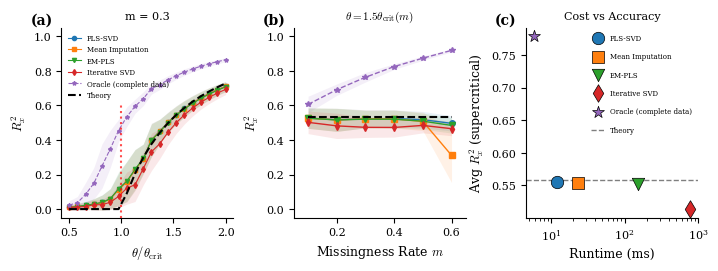


Figure saved: ../figures/figA3_comparison.pdf


In [5]:
fig = plt.figure(figsize=(7.0, 2.5))
gs = gridspec.GridSpec(1, 3, wspace=0.35,
                       left=0.07, right=0.98, bottom=0.16, top=0.92)

ax_a = fig.add_subplot(gs[0])
ax_b = fig.add_subplot(gs[1])
ax_c = fig.add_subplot(gs[2])

# --- Panel (a): Phase transition curves for all methods ---
results_a = all_results['exp_a']

for method_name, info in METHODS.items():
    key_mean = f"{info['key']}_mean"
    key_std = f"{info['key']}_std"
    
    theta_norm = [r['theta_norm'] for r in results_a]
    rx2_mean = [r[key_mean] for r in results_a]
    rx2_std = [r[key_std] for r in results_a]
    
    ax_a.plot(theta_norm, rx2_mean,
              marker=info['marker'], markersize=3, linewidth=0.8,
              linestyle=info['linestyle'],
              color=info['color'], label=info['label'])
    ax_a.fill_between(theta_norm,
                      np.array(rx2_mean) - np.array(rx2_std),
                      np.array(rx2_mean) + np.array(rx2_std),
                      color=info['color'], alpha=0.1, linewidth=0)

# MCAR Theory curve
ax_a.plot([r['theta_norm'] for r in results_a],
          [r['Rx2_theory'] for r in results_a],
          'k--', linewidth=1.5, label='Theory', zorder=10)

ax_a.axvline(1.0, ymax=0.6, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
ax_a.set_xlabel(r'$\theta / \theta_{\mathrm{crit}}$')
ax_a.set_ylabel(r'$R_x^2$')
ax_a.set_ylim([-0.05, 1.05])
ax_a.legend(loc='upper left', frameon=False, fontsize=5, ncol=1)
ax_a.set_title(f'm = {m_fixed}', fontsize=8)
ax_a.text(-0.18, 1.08, '(a)', transform=ax_a.transAxes,
          fontsize=10, fontweight='bold', va='top')

# --- Panel (b): Method comparison across missingness rates ---
results_b = all_results['exp_b']
m_plot = [r['m'] for r in results_b]

for method_name, info in METHODS.items():
    key_mean = f"{info['key']}_mean"
    key_std = f"{info['key']}_std"
    
    rx2_mean = [r[key_mean] for r in results_b]
    rx2_std = [r[key_std] for r in results_b]
    
    ax_b.plot(m_plot, rx2_mean,
              marker=info['marker'], markersize=4, linewidth=1,
              linestyle=info['linestyle'],
              color=info['color'], label=info['label'])
    ax_b.fill_between(m_plot,
                      np.array(rx2_mean) - np.array(rx2_std),
                      np.array(rx2_mean) + np.array(rx2_std),
                      color=info['color'], alpha=0.1, linewidth=0)

# Theory prediction (computed for each m)
theory_vals = [r['Rx2_theory'] for r in results_b]
ax_b.plot(m_plot, theory_vals, 'k--', linewidth=1.5, label='Theory', zorder=10)

ax_b.set_xlabel('Missingness Rate $m$')
ax_b.set_ylabel(r'$R_x^2$')
ax_b.set_ylim([-0.05, 1.05])
ax_b.set_xlim([0.05, 0.65])
ax_b.set_title(r'$\theta = 1.5\theta_{\mathrm{crit}}(m)$', fontsize=8)
ax_b.text(-0.18, 1.08, '(b)', transform=ax_b.transAxes,
          fontsize=10, fontweight='bold', va='top')

# --- Panel (c): Computational cost vs accuracy ---
# Aggregate across all experiments for runtime
method_stats = {}
for method_name, info in METHODS.items():
    key_mean = f"{info['key']}_mean"
    time_key_mean = f"{info['time_key']}_mean"
    
    # Average accuracy across theta sweep (supercritical only)
    supercrit_results = [r for r in results_a if r['theta_norm'] > 1.2]
    if supercrit_results:
        avg_rx2 = np.mean([r[key_mean] for r in supercrit_results])
        avg_time = np.mean([r[time_key_mean] for r in supercrit_results])
        method_stats[method_name] = {'rx2': avg_rx2, 'time': avg_time}

# Plot
for method_name, info in METHODS.items():
    if method_name in method_stats:
        stats = method_stats[method_name]
        ax_c.scatter(stats['time'] * 1000, stats['rx2'],  # Convert to ms
                    s=80, c=info['color'], marker=info['marker'],
                    edgecolors='black', linewidths=0.5, zorder=5,
                    label=info['label'])

# Add horizontal line for theory
theory_supercrit = np.mean([r['Rx2_theory'] for r in supercrit_results])
ax_c.axhline(theory_supercrit, color='k', linestyle='--', linewidth=1, alpha=0.5,
             label='Theory')

ax_c.set_xlabel('Runtime (ms)')
ax_c.set_ylabel(r'Avg $R_x^2$ (supercritical)')
ax_c.set_xscale('log')
ax_c.legend(loc='upper right', frameon=False, fontsize=5, ncol=1, labelspacing=1.5)
ax_c.set_title('Cost vs Accuracy', fontsize=8)
ax_c.text(-0.18, 1.08, '(c)', transform=ax_c.transAxes,
          fontsize=10, fontweight='bold', va='top')

plt.savefig('../figures/figA3_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\nFigure saved: ../figures/figA3_comparison.pdf")